# H&M Customer Analytics — Разведочный анализ данных (EDA)

**Датасет:** H&M Personalized Fashion Recommendations (Kaggle)
**Источник:** ClickHouse (база `hm`), 3 таблицы — transactions, customers, articles
**Период данных:** 2018-09-20 — 2020-09-22

## Цель ноутбука
Оценить качество данных, выявить пропуски/дубли/аномалии, изучить распределения ключевых переменных и сформулировать гипотезы для дальнейшего анализа (когорты, RFM, каналы, churn).

## Структура
0. Настройка окружения и подключение
1. Обзор данных
2. Качество данных (пропуски, дубли, целостность)
3. Профилирование переменных
4. Первые гипотезы
5. Решения по очистке

## 0. Настройка окружения и подключение к ClickHouse

In [1]:
import clickhouse_connect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Подключение к ClickHouse
client = clickhouse_connect.get_client(
    host='localhost',
    port=8123,
    username='analyst',
    password='analyst',
    database='hm'
)

# Проверка связи
print(client.query('SELECT version()').result_rows[0][0])

24.8.14.39


In [2]:
def q(sql: str) -> pd.DataFrame:
    """Выполнить SQL в ClickHouse и вернуть результат как pandas DataFrame."""
    return client.query_df(sql)

# Тест: данные на месте?
q("""
SELECT
    'transactions' AS table, count() AS rows FROM hm.transactions
UNION ALL SELECT 'customers', count() FROM hm.customers
UNION ALL SELECT 'articles', count() FROM hm.articles
""")

,table,rows
0,articles,105542
1,transactions,31788324
2,customers,1371980


## 1. Обзор данных

Знакомство со структурой трёх таблиц: схема, типы колонок, примеры строк.
Цель — понять что за поля доступны и в каком они виде, прежде чем считать метрики.

In [3]:
print("TRANSACTIONS")
display(q("DESCRIBE hm.transactions"))

print("CUSTOMERS")
display(q("DESCRIBE hm.customers"))

print("ARTICLES")
display(q("DESCRIBE hm.articles"))

TRANSACTIONS


,name,type,default_type,default_expression,comment,codec_expression,ttl_expression
0,t_dat,Date,,,,,
1,customer_id,FixedString(64),,,,,
2,article_id,UInt32,,,,,
3,price,Float32,,,,,
4,sales_channel_id,UInt8,,,,,


CUSTOMERS


,name,type,default_type,default_expression,comment,codec_expression,ttl_expression
0,customer_id,FixedString(64),,,,,
1,FN,Nullable(Float32),,,,,
2,Active,Nullable(Float32),,,,,
3,club_member_status,LowCardinality(String),,,,,
4,fashion_news_frequency,LowCardinality(String),,,,,
5,age,Nullable(UInt8),,,,,
6,postal_code,FixedString(64),,,,,


ARTICLES


,name,type,default_type,default_expression,comment,codec_expression,ttl_expression
0,article_id,UInt32,,,,,
1,product_code,UInt32,,,,,
2,prod_name,String,,,,,
3,product_type_no,Int32,,,,,
4,product_type_name,LowCardinality(String),,,,,
5,product_group_name,LowCardinality(String),,,,,
6,graphical_appearance_no,Int32,,,,,
7,graphical_appearance_name,LowCardinality(String),,,,,
8,colour_group_code,Int32,,,,,
9,colour_group_name,LowCardinality(String),,,,,


### 1.1 Примеры строк

Смотрим по 5 реальных строк из каждой таблицы — как выглядят данные «вживую».

In [4]:
display(q("SELECT * FROM hm.transactions LIMIT 5"))
display(q("SELECT * FROM hm.customers LIMIT 5"))
display(q("SELECT * FROM hm.articles LIMIT 5"))

,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-21,b'0000423b00ade91418cceaf3b26c6af3dd342b51fd05...,583558001,0.07,2
1,2018-09-21,b'0000423b00ade91418cceaf3b26c6af3dd342b51fd05...,639677008,0.03,2
2,2018-09-21,b'0000423b00ade91418cceaf3b26c6af3dd342b51fd05...,640244003,0.03,2
3,2018-09-25,b'0000423b00ade91418cceaf3b26c6af3dd342b51fd05...,521269001,0.03,2
4,2018-09-25,b'0000423b00ade91418cceaf3b26c6af3dd342b51fd05...,666448006,0.03,2


,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,b'00000dbacae5abe5e23885899a1fa44253a17956c6d1...,NaN,NaN,ACTIVE,NONE,49,b'52043ee2162cf5aa7ee79974281641c6f11a68d27642...
1,b'0000423b00ade91418cceaf3b26c6af3dd342b51fd05...,NaN,NaN,ACTIVE,NONE,25,b'2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d...
2,b'000058a12d5b43e67d225668fa1f8d618c13dc232df0...,NaN,NaN,ACTIVE,NONE,24,b'64f17e6a330a85798e4998f62d0930d14db8db1c054a...
3,b'00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1b...,NaN,NaN,ACTIVE,NONE,54,b'5d36574f52495e81f019b680c843c443bd343d5ca5b1...
4,b'00006413d8573cd20ed7128e53b7b13819fe5cfc2d80...,1.00,1.00,ACTIVE,Regularly,52,b'25fa5ddee9aac01b35208d01736e57942317d756b32d...


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,perceived_colour_value_id,perceived_colour_value_name,perceived_colour_master_id,perceived_colour_master_name,department_no,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,4,Dark,5,Black,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,3,Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,1,Dusty Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,4,Dark,5,Black,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,3,Light,9,White,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


## 2. Качество данных

Проверяем три вещи:
- **Пропуски** — какие поля и насколько заполнены
- **Дубли** — есть ли полностью дублирующиеся транзакции
- **Целостность связей** — все ли customer_id и article_id из транзакций есть в справочниках

### Таблица trasactions

Проверяем: есть ли строки с одинаковым (t_dat, customer_id, article_id, price, sales_channel_id).
Полный дубль — вероятно, ошибка загрузки или двойная запись кассы.

In [5]:
dupes = q("""
SELECT
    count() AS total_rows,
    countDistinct(t_dat, customer_id, article_id, price, sales_channel_id)
                                                        AS unique_rows,
    total_rows - unique_rows AS duplicate_rows,
    round((total_rows - unique_rows) * 100.0 / total_rows, 3)
                                                        AS duplicate_pct
FROM hm.transactions
""")
display(dupes)

,total_rows,unique_rows,duplicate_rows,duplicate_pct
0,31788324,28813419,2974905,9.36


Найдено 2.97M дублирующихся строк (9.36%) — клиент купил одинаковый товар
несколько раз в один день. Это особенность fashion-ритейла, не баг.
Строки оставляем — каждая отражает реальную транзакцию.

In [6]:
prices = q("""
SELECT
    min(price)      AS min_price,
    max(price)      AS max_price,
    round(avg(price), 5) AS avg_price,
    countIf(price <= 0) AS zero_or_negative
FROM hm.transactions
""")
display(prices)

,min_price,max_price,avg_price,zero_or_negative
0,0.00,0.59,0.03,0


Нулевых или отрицательных цен нет.
Цены нормализованы (max=0.59, avg=0.03) — абсолютные значения
не интерпретируем, работаем с относительными для RFM и сегментации.

In [7]:
channels = q("""
SELECT
    sales_channel_id,
    count() AS transactions,
    round(count() * 100.0 / sum(count()) OVER (), 1) AS pct,
    uniq(customer_id) AS uniq_customers
FROM hm.transactions
GROUP BY sales_channel_id
ORDER BY sales_channel_id
""")
display(channels)

,sales_channel_id,transactions,pct,uniq_customers
0,1,9408462,29.60,739676
1,2,22379862,70.40,1112765


### 2.2 Таблица customers

In [8]:
miss = q("""
SELECT
    countIf(FN IS NULL)                     AS fn_null,
    countIf(Active IS NULL)                 AS active_null,
    countIf(club_member_status = '')        AS club_status_empty,
    countIf(fashion_news_frequency = '')    AS news_freq_empty,
    countIf(age IS NULL)                    AS age_null,
    countIf(postal_code = '')               AS postal_null,
    count()                                 AS total
FROM hm.customers
""")

# Пересчитаем в проценты
total = miss['total'].iloc[0]
miss_pct = miss.drop(columns='total').div(total).mul(100).round(1)
miss_pct['total_rows'] = total
display(miss_pct)

,fn_null,active_null,club_status_empty,news_freq_empty,age_null,postal_null,total_rows
0,65.20,66.20,0.40,1.20,1.20,0.00,1371980


FN и Active заполнены лишь на 34-35% — колонки исключаем из анализа.

In [9]:
cats = q("""
SELECT
    uniq(club_member_status)       AS club_status_uniq,
    uniq(fashion_news_frequency)   AS news_freq_uniq,
    uniq(postal_code)              AS postal_uniq
FROM hm.customers
""")
display(cats)

# Какие именно значения в club_member_status и fashion_news_frequency
display(q("""
SELECT club_member_status, fashion_news_frequency, count() AS cnt
FROM hm.customers
GROUP BY club_member_status, fashion_news_frequency
ORDER BY cnt DESC
"""))

,club_status_uniq,news_freq_uniq,postal_uniq
0,4,5,352127


,club_member_status,fashion_news_frequency,cnt
0,ACTIVE,NONE,788482
1,ACTIVE,Regularly,471304
2,PRE-CREATE,NONE,85065
3,ACTIVE,,11925
4,PRE-CREATE,Regularly,5787
5,,NONE,3705
6,PRE-CREATE,,2049
7,,,2035
8,ACTIVE,Monthly,778
9,LEFT CLUB,NONE,459


club_member_status: 3 значимых статуса (ACTIVE, PRE-CREATE, LEFT CLUB) +
  ~8K строк с пустой строкой. Позже сгруппируем в "Unknown" при агрегациях.

fashion_news_frequency: значения "None" и "NONE" — один смысл но разный регистр.
  Нормализуем при использовании через UPPER().

,age_group,cnt,pct
0,20-29,528358,38.50
1,30-39,234068,17.10
2,40-49,204118,14.90
3,50-59,226242,16.50
4,60-69,72623,5.30
5,70+,19127,1.40
6,<20,71583,5.20
7,NULL,15861,1.20


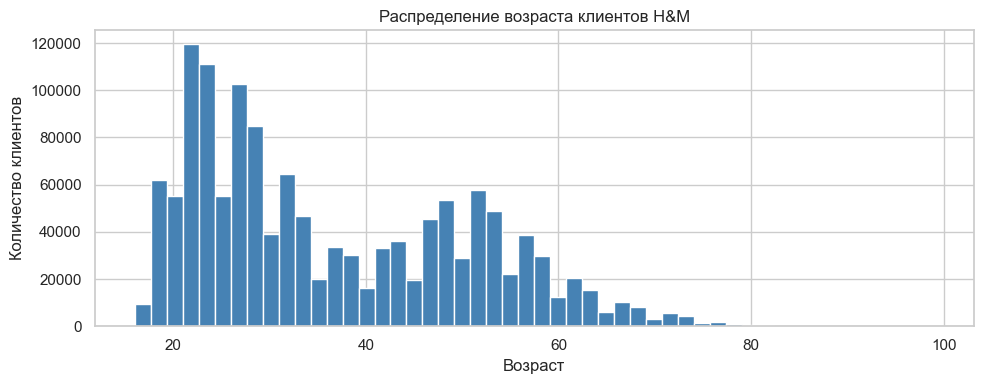

In [10]:
age_dist = q("""
SELECT
    multiIf(
        age IS NULL,      'NULL',
        age < 20,         '<20',
        age < 30,         '20-29',
        age < 40,         '30-39',
        age < 50,         '40-49',
        age < 60,         '50-59',
        age < 70,         '60-69',
                          '70+'
    ) AS age_group,
    count() AS cnt,
    round(count() * 100.0 / sum(count()) OVER (), 1) AS pct
FROM hm.customers
GROUP BY age_group
ORDER BY age_group
""")
display(age_dist)

# Гистограмма
age_vals = q("SELECT age FROM hm.customers WHERE age IS NOT NULL")
plt.figure(figsize=(10, 4))
plt.hist(age_vals['age'], bins=50, color='steelblue', edgecolor='white')
plt.title('Распределение возраста клиентов H&M')
plt.xlabel('Возраст')
plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

Возраст: пропусков всего 1.2%, можно работать. Основная аудитория — 20-29 лет (38.5%).
  Неожиданно большой сегмент 50-59 лет (16.5%).

### 2.2 Таблица articles

In [11]:
art_quality = q("""
SELECT
    count()                AS total_rows,
    uniq(article_id)       AS uniq_articles,
    uniq(product_code)     AS uniq_products,
    countIf(prod_name = '') AS empty_names,
    countIf(detail_desc = '') AS empty_desc
FROM hm.articles
""")
display(art_quality)

,total_rows,uniq_articles,uniq_products,empty_names,empty_desc
0,105542,105228,47224,0,416



- 105 228 уникальных article_id из 105 542 строк → есть ~314 повторов article_id
  (вероятно дубли описаний одного SKU), некритично для анализа.
- 47 224 уникальных product_code → в среднем ~2 цвета/варианта на продукт.
- Пустых названий нет, 416 товаров без detail_desc (0.4%) — некритично.

### 2.4 Целостность связей (referential integrity)

Проверяем: все ли customer_id из транзакций присутствуют в таблице customers?
Все ли article_id из транзакций присутствуют в articles?

In [12]:
integrity = q("""
SELECT
    (
        SELECT uniq(t.customer_id)
        FROM hm.transactions t
        LEFT JOIN hm.customers c ON t.customer_id = c.customer_id
        WHERE c.customer_id = ''
    ) AS customers_missing_in_dim,
    (
        SELECT uniq(t.article_id)
        FROM hm.transactions t
        LEFT JOIN hm.articles a ON t.article_id = a.article_id
        WHERE a.article_id = 0
    ) AS articles_missing_in_dim
""")
display(integrity)

,customers_missing_in_dim,articles_missing_in_dim
0,0,0


**Целостность связей: OK.** Все customer_id и article_id из транзакций
присутствуют в справочниках. JOIN-ы не потеряют данные.

## 3. Профилирование переменных

Изучаем распределения ключевых метрик и ищем закономерности для дальнейшего анализа
(когорты, RFM, каналы, churn).

### 3.1 Динамика во времени

Выручка, число транзакций и уникальных клиентов по месяцам.
Ищем сезонность и эффект COVID-19 (локдаун весны 2020).

In [13]:
monthly = q("""
SELECT
    toStartOfMonth(t_dat)         AS month,
    count()                       AS transactions,
    uniq(customer_id)             AS customers,
    round(sum(price), 0)          AS revenue,
    round(avg(price), 4)          AS avg_price
FROM hm.transactions
GROUP BY month
ORDER BY month
""")
display(monthly)

,month,transactions,customers,revenue,avg_price
0,2018-09-01,594776,140218,"17,756.00",0.03
1,2018-10-01,1397040,274483,"41,585.00",0.03
2,2018-11-01,1270619,273906,"39,001.00",0.03
3,2018-12-01,1148827,253493,"32,533.00",0.03
4,2019-01-01,1263471,242254,"33,450.00",0.03
5,2019-02-01,1152412,238416,"31,428.00",0.03
6,2019-03-01,1286750,244375,"37,549.00",0.03
7,2019-04-01,1476454,261260,"42,825.00",0.03
8,2019-05-01,1560319,273249,"43,358.00",0.03
9,2019-06-01,1906202,304688,"48,648.00",0.03


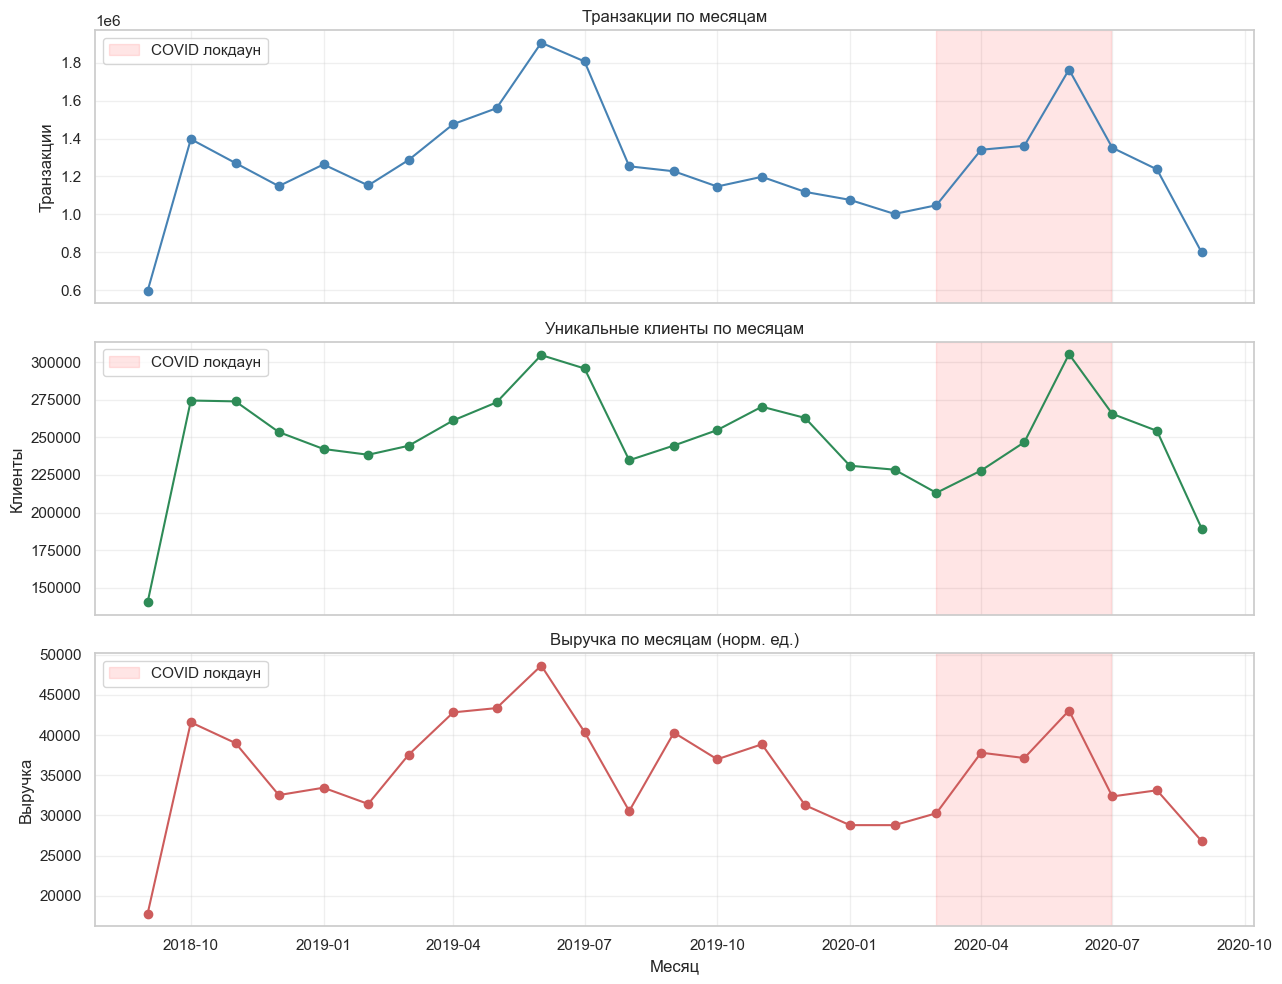

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# Транзакции
axes[0].plot(monthly['month'], monthly['transactions'], marker='o', color='steelblue')
axes[0].set_title('Транзакции по месяцам')
axes[0].set_ylabel('Транзакции')

# Уникальные клиенты
axes[1].plot(monthly['month'], monthly['customers'], marker='o', color='seagreen')
axes[1].set_title('Уникальные клиенты по месяцам')
axes[1].set_ylabel('Клиенты')

# Выручка
axes[2].plot(monthly['month'], monthly['revenue'], marker='o', color='indianred')
axes[2].set_title('Выручка по месяцам (норм. ед.)')
axes[2].set_ylabel('Выручка')

# Подсветим период COVID-локдауна (март-май 2020)
for ax in axes:
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-30'),
               color='red', alpha=0.1, label='COVID локдаун')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.xlabel('Месяц')
plt.tight_layout()
plt.show()

**Динамика транзакций / клиентов / выручки (весь период):**
- Три метрики движутся почти синхронно — сильная корреляция.
  Значит выручка определяется в основном количеством транзакций,
  а не изменением среднего чека (чек стабилен).
- Весь COVID-год идёт ниже спокойного года по объёму, но клиентская
  база при этом не схлопнулась.

In [15]:
trailing = q("""
SELECT
    'A: 2018-09-20 .. 2019-09-22 (до COVID)' AS period,
    count()             AS transactions,
    uniq(customer_id)   AS customers,
    round(sum(price), 0) AS revenue
FROM hm.transactions
WHERE t_dat BETWEEN '2018-09-20' AND '2019-09-22'

UNION ALL

SELECT
    'B: 2019-09-20 .. 2020-09-22 (COVID-год)' AS period,
    count(),
    uniq(customer_id),
    round(sum(price), 0)
FROM hm.transactions
WHERE t_dat BETWEEN '2019-09-20' AND '2020-09-22'
""")
display(trailing)

# Посчитаем разницу в процентах
a = trailing.iloc[0]
b = trailing.iloc[1]
for col in ['transactions', 'customers', 'revenue']:
    change = (b[col] - a[col]) / a[col] * 100
    print(f"{col:15s}: {change:+.1f}%")

,period,transactions,customers,revenue
0,B: 2019-09-20 .. 2020-09-22 (COVID-год),14984423,998900,"423,139.00"
1,A: 2018-09-20 .. 2019-09-22 (до COVID),16889901,1008492,"464,355.00"


transactions   : +12.7%
customers      : +1.0%
revenue        : +9.7%


Сравнив скользящие года видим, что клиентская база устойчива, падает интенсивность покупок.

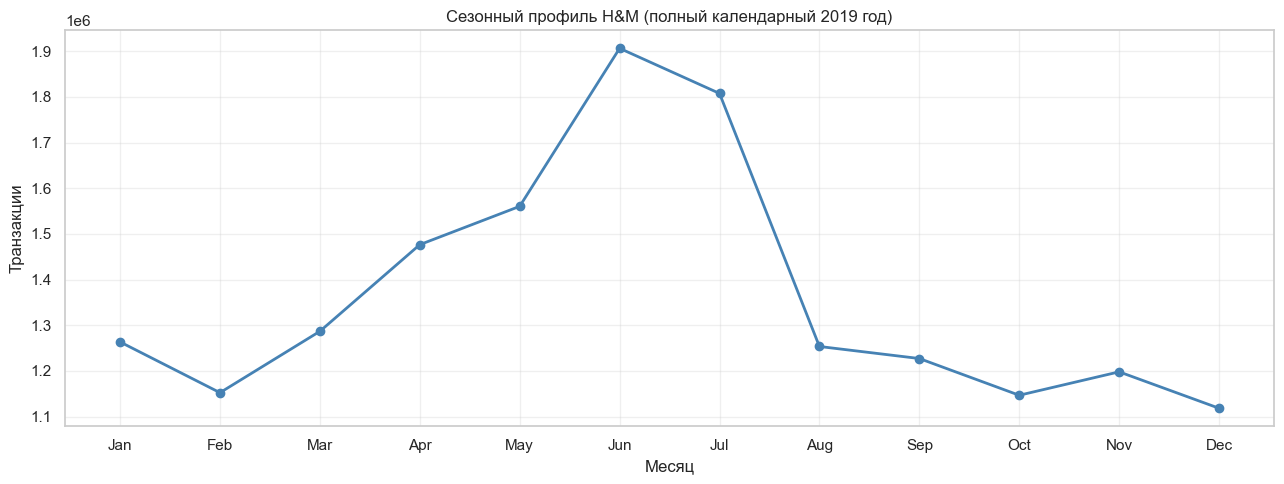

In [16]:
season_2019 = q("""
SELECT
    toMonth(t_dat) AS month_num,
    count()        AS transactions,
    uniq(customer_id) AS customers,
    round(sum(price), 0) AS revenue
FROM hm.transactions
WHERE toYear(t_dat) = 2019
GROUP BY month_num
ORDER BY month_num
""")

import calendar
plt.figure(figsize=(13, 5))
plt.plot(season_2019['month_num'], season_2019['transactions'],
         marker='o', color='steelblue', linewidth=2)
plt.title('Сезонный профиль H&M (полный календарный 2019 год)')
plt.xlabel('Месяц')
plt.ylabel('Транзакции')
plt.xticks(range(1, 13), [calendar.month_abbr[m] for m in range(1, 13)])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Сезонный профиль (календарный 2019):**
- Чёткий годовой цикл: минимум в феврале, резкий рост весной,
  пик в июне (~1.9M транзакций), обвал в августе почти в полтора раза.
- Вторая половина года (Aug–Dec) стабильно ниже первой —
  выраженной осенней волны нет.
- Природа летнего пика не ясна из этих данных: это может быть
  распродажа (больше дешёвых покупок) или сезонный спрос.
  → проверим в 3.2 (цены) и 3.4 (категории).

### 3.2 Цены и каналы продаж

Изучаем распределение цен, динамику средней цены во времени
(проверка гипотезы о летней распродаже) и соотношение онлайн/офлайн.

,median,p90,p99,max
0,0.03,0.05,0.10,0.59


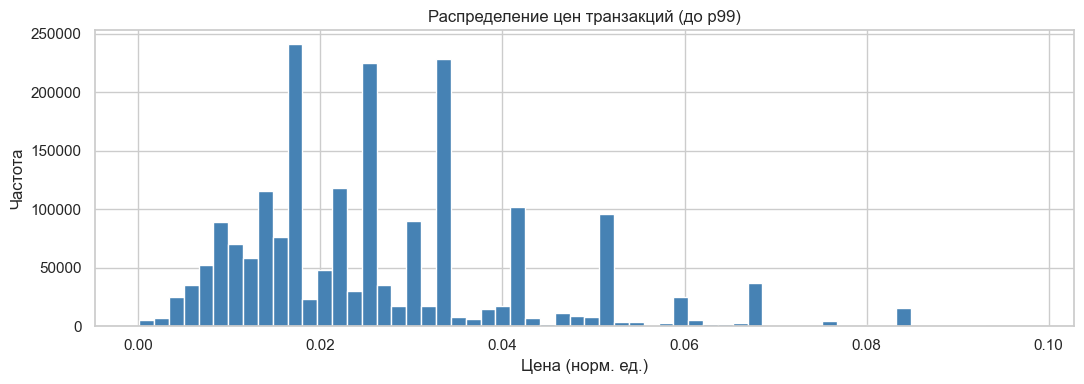

In [17]:
price_dist = q("""
SELECT
    round(quantile(0.50)(price), 4) AS median,
    round(quantile(0.90)(price), 4) AS p90,
    round(quantile(0.99)(price), 4) AS p99,
    round(max(price), 4)            AS max
FROM hm.transactions
""")
display(price_dist)

# Гистограмма цен (обрежем хвост по p99 чтобы было видно основную массу)
p99 = price_dist['p99'].iloc[0]
prices = q(f"SELECT price FROM hm.transactions WHERE price <= {p99} LIMIT 2000000")
plt.figure(figsize=(11, 4))
plt.hist(prices['price'], bins=60, color='steelblue', edgecolor='white')
plt.title('Распределение цен транзакций (до p99)')
plt.xlabel('Цена (норм. ед.)')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

- Распределение правоскошенное: большинство покупок в дешёвом диапазоне,
  длинный хвост дорогих товаров. Дискретные пики — эффект нормализации
  психологических ценовых точек.

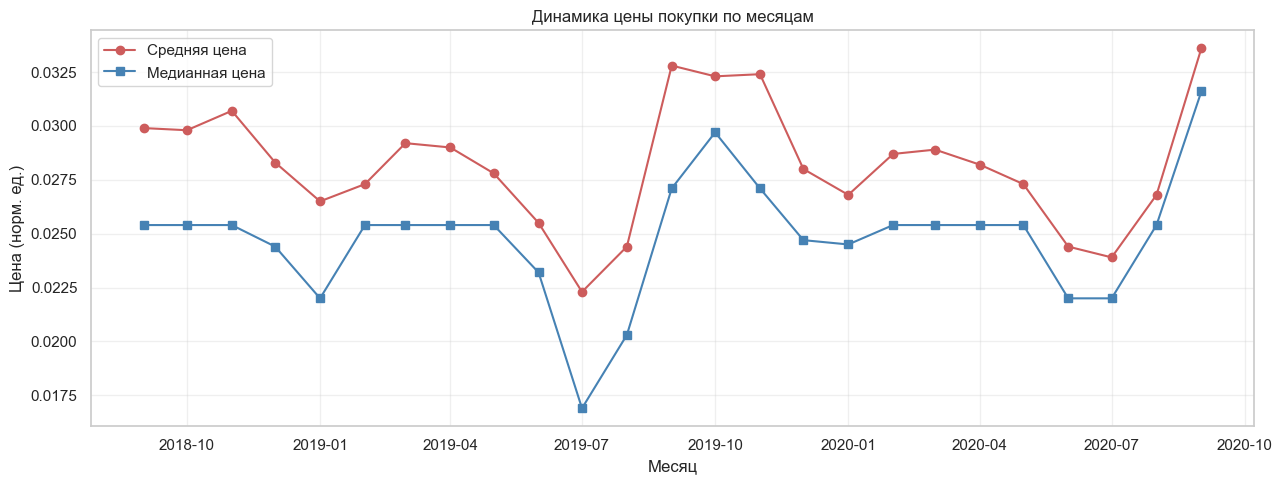

In [18]:
price_time = q("""
SELECT
    toStartOfMonth(t_dat) AS month,
    round(avg(price), 4)  AS avg_price,
    round(median(price), 4) AS median_price
FROM hm.transactions
GROUP BY month
ORDER BY month
""")

plt.figure(figsize=(13, 5))
plt.plot(price_time['month'], price_time['avg_price'], marker='o', label='Средняя цена', color='indianred')
plt.plot(price_time['month'], price_time['median_price'], marker='s', label='Медианная цена', color='steelblue')
plt.title('Динамика цены покупки по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Цена (норм. ед.)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


В июне-июле 2019 синхронно упали и средняя, и медианная цена.
Падение медианы исключает влияние выбросов → сдвинулась вся масса цен.
Это сильный сигнал в пользу летней распродажи.
Полностью исключить mix shift (сдвиг в дешёвые летние категории)
нельзя без анализа на уровне SKU — фиксируем как гипотезу.

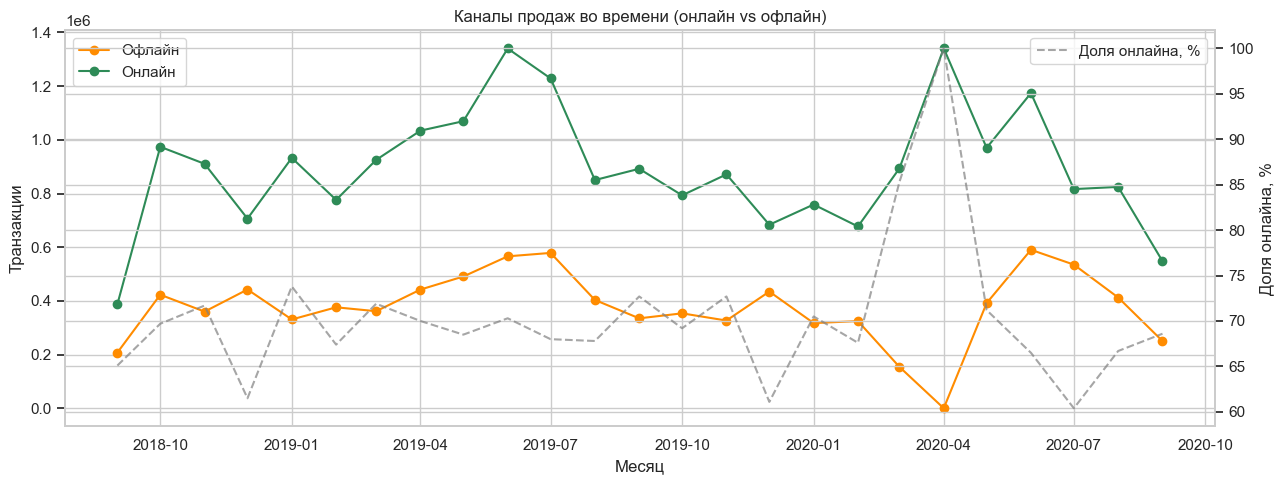

In [19]:
channel_time = q("""
SELECT
    toStartOfMonth(t_dat) AS month,
    countIf(sales_channel_id = 1) AS offline,
    countIf(sales_channel_id = 2) AS online,
    round(countIf(sales_channel_id = 2) * 100.0 / count(), 1) AS online_share_pct
FROM hm.transactions
GROUP BY month
ORDER BY month
""")

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(channel_time['month'], channel_time['offline'], marker='o', label='Офлайн', color='darkorange')
ax1.plot(channel_time['month'], channel_time['online'], marker='o', label='Онлайн', color='seagreen')
ax1.set_ylabel('Транзакции')
ax1.set_xlabel('Месяц')
ax1.legend(loc='upper left')

# Вторая ось — доля онлайна
ax2 = ax1.twinx()
ax2.plot(channel_time['month'], channel_time['online_share_pct'],
         linestyle='--', color='gray', alpha=0.7, label='Доля онлайна, %')
ax2.set_ylabel('Доля онлайна, %')
ax2.legend(loc='upper right')

plt.title('Каналы продаж во времени (онлайн vs офлайн)')
plt.tight_layout()
plt.show()

- Онлайн доминирует (70% транзакций за весь период).
- В апреле 2020 офлайн-транзакции упали практически до нуля,
  доля онлайна → ~100%. 
- Офлайн и онлайн двигаются в целом синхронно по сезонности —
  сезонность не зависит от канала.

### 3.3 Демография клиентов

Смотрим на возраст и статус клуба в связке с покупательской активностью.
Вопрос: отличается ли поведение разных возрастных групп?

In [20]:
demo = q("""
SELECT
    multiIf(
        age < 20,  '<20',
        age < 30,  '20-29',
        age < 40,  '30-39',
        age < 50,  '40-49',
        age < 60,  '50-59',
        age < 70,  '60-69',
                   '70+'
    ) AS age_group,
    club_member_status,
    count(DISTINCT c.customer_id)           AS customers,
    round(avg(tx.tx_count), 1)              AS avg_transactions,
    round(avg(tx.total_spent), 3)           AS avg_spent
FROM hm.customers c
LEFT JOIN (
    SELECT
        customer_id,
        count()       AS tx_count,
        sum(price)    AS total_spent
    FROM hm.transactions
    GROUP BY customer_id
) tx ON c.customer_id = tx.customer_id
WHERE age IS NOT NULL
  AND club_member_status IN ('ACTIVE', 'PRE-CREATE', 'LEFT CLUB')
GROUP BY age_group, club_member_status
ORDER BY age_group, club_member_status
""")
display(demo)

,age_group,club_member_status,customers,avg_transactions,avg_spent
0,20-29,ACTIVE,504713,25.50,0.69
1,20-29,LEFT CLUB,203,17.60,0.52
2,20-29,PRE-CREATE,22258,7.30,0.21
3,30-39,ACTIVE,215301,29.10,0.81
4,30-39,LEFT CLUB,86,27.30,0.80
5,30-39,PRE-CREATE,17907,8.40,0.25
6,40-49,ACTIVE,185728,25.70,0.71
7,40-49,LEFT CLUB,48,16.40,0.51
8,40-49,PRE-CREATE,17556,7.20,0.21
9,50-59,ACTIVE,206208,24.20,0.71


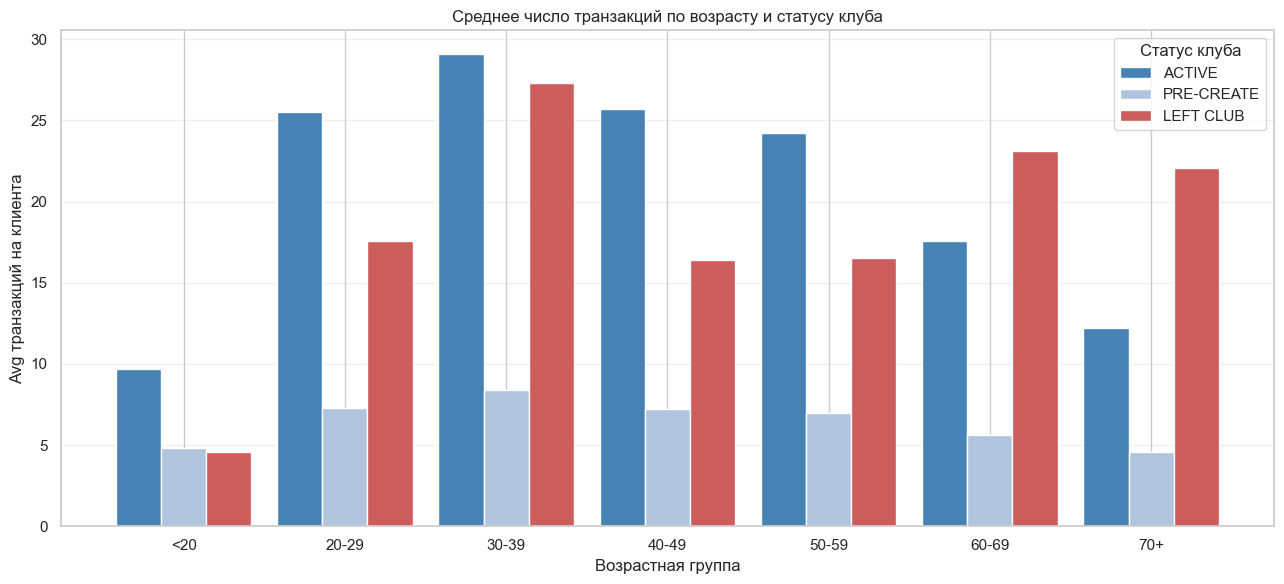

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Оставляем только нужные статусы и сортируем группы
order = ['<20','20-29','30-39','40-49','50-59','60-69','70+']
statuses = ['ACTIVE', 'PRE-CREATE', 'LEFT CLUB']
colors = {'ACTIVE': 'steelblue', 'PRE-CREATE': 'lightsteelblue', 'LEFT CLUB': 'indianred'}

demo_pivot = demo.pivot(index='age_group', columns='club_member_status', values='avg_transactions')
demo_pivot = demo_pivot.reindex(order)[statuses]

x = np.arange(len(order))
width = 0.28

fig, ax = plt.subplots(figsize=(13, 6))
for i, status in enumerate(statuses):
    ax.bar(x + i*width, demo_pivot[status], width,
           label=status, color=colors[status], edgecolor='white')

ax.set_title('Среднее число транзакций по возрасту и статусу клуба')
ax.set_xlabel('Возрастная группа')
ax.set_ylabel('Avg транзакций на клиента')
ax.set_xticks(x + width)
ax.set_xticklabels(order)
ax.legend(title='Статус клуба')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

- ACTIVE-клиенты покупают в 3-4 раза чаще PRE-CREATE во всех
  возрастных группах. Статус клуба — сильнейший предиктор активности,
  сильнее чем возраст.
- Пик активности по возрасту — группа 30-39 (avg 29 транзакций),
  самые неактивные — 70+ и <20.
- LEFT CLUB ведёт себя неустойчиво (маленькая выборка) —
  не интерпретируем как тренд.
→ Статус клуба войдёт как фича в churn-модель (Блок 5).

### 3.4 Категории товаров

Что покупают чаще всего? Смотрим на product_group_name и index_group_name.

,product_group_name,transactions,uniq_customers,avg_price,pct
0,Garment Upper body,12552755,1099291,0.03,39.50
1,Garment Lower body,7046054,929977,0.03,22.20
2,Garment Full body,3552470,645569,0.04,11.20
3,Swimwear,2579222,426426,0.02,8.10
4,Underwear,2565858,517385,0.02,8.10
5,Accessories,1599593,492926,0.02,5.00
6,Shoes,745521,269972,0.04,2.30
7,Socks & Tights,685712,266474,0.01,2.20
8,Nightwear,348180,169206,0.03,1.10
9,Unknown,97040,64344,0.03,0.30


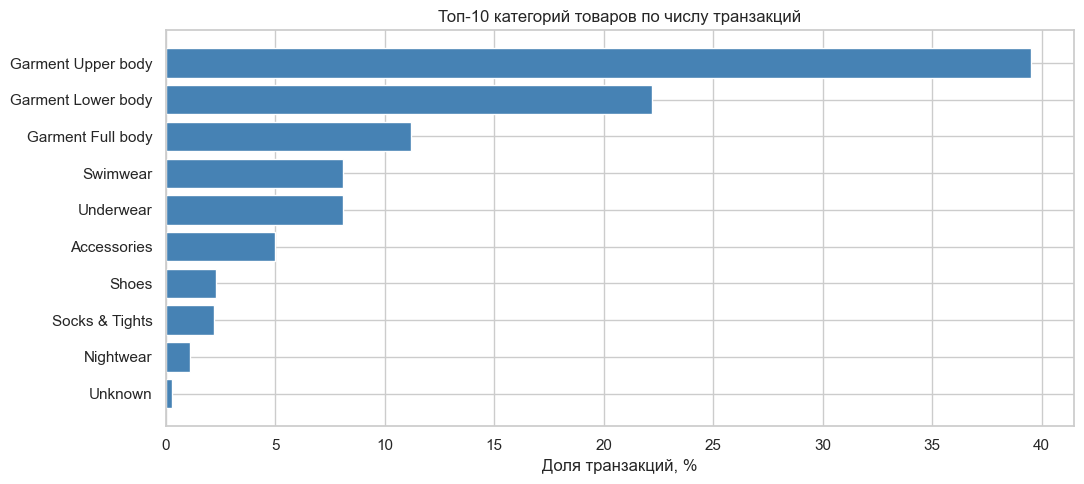

In [21]:
cats = q("""
SELECT
    a.product_group_name,
    count()                          AS transactions,
    uniq(t.customer_id)              AS uniq_customers,
    round(avg(t.price), 4)           AS avg_price,
    round(count() * 100.0 /
        sum(count()) OVER (), 1)     AS pct
FROM hm.transactions t
INNER JOIN hm.articles a ON t.article_id = a.article_id
GROUP BY a.product_group_name
ORDER BY transactions DESC
LIMIT 10
""")
display(cats)

# Визуализация
plt.figure(figsize=(11, 5))
plt.barh(cats['product_group_name'][::-1], cats['pct'][::-1], color='steelblue')
plt.title('Топ-10 категорий товаров по числу транзакций')
plt.xlabel('Доля транзакций, %')
plt.tight_layout()
plt.show()

- Garment Upper body доминирует с отрывом (40% транзакций),
  следом Lower body (22%) и Full body (11%).
  Три категории дают ~73% всех транзакций — высокая концентрация.
- Swimwear и Underwear на 4-5 месте (~8% каждая) — не маргинальные.
- Unknown (~0.3%) — артефакт данных (товары без категории из EDA).
- Сезонность категорий не проверялась здесь — выносим в гипотезы.

## 4. Гипотезы для проверки в следующих блоках

По итогам EDA сформулированы следующие гипотезы:

**Г1. Летний пик транзакций обусловлен распродажей, а не сезонным спросом.**
Признак: синхронное падение средней и медианной цены в июне-июле.
Проверка: анализ категорий × месяц (Блок 3, каналы).

**Г2. Omnichannel-клиенты (покупают и онлайн, и офлайн) ценнее
single-channel по частоте и выручке.**
Признак: онлайн доминирует (70%), но офлайн-клиенты никуда не исчезли.
Проверка: сегментация по каналам (Блок 3).

**Г3. Статус клуба (ACTIVE vs PRE-CREATE) — значимый предиктор оттока.**
Признак: ACTIVE покупают в 3-4 раза чаще PRE-CREATE во всех возрастах.
Проверка: churn-модель, важность фичей (Блок 5).

**Г4. Retention упал в когортах периода COVID (весна 2020).**
Признак: общий спад транзакций в марте-апреле 2020.
Проверка: когортный анализ retention (Блок 1).

## 5. Решения по очистке данных

| Находка | Решение | Обоснование |
|---|---|---|
| 2.97M дублей транзакций (9.36%) | Оставляем | Реальные повторные покупки |
| FN, Active — 65%+ пропусков | Исключаем из анализа | Нет информативности |
| club_member_status = '' (~8K) | Группируем в 'Unknown' | Артефакт выгрузки |
| fashion_news_frequency: 'None' и 'NONE' | Нормализуем через UPPER() при использовании | Разный регистр, один смысл |
| age IS NULL (~15K, 1.2%) | Исключаем из возрастных срезов, в общих метриках оставляем | Мало, некритично |
| 416 товаров без detail_desc | Оставляем | Не влияет на анализ |
| Сентябрь 2020 неполный | Исключаем из YoY-сравнений | Артефакт обрезки данных |